### Goal
To determine whether candidate outcomes (scores, unlocks, rejections) differ across demographic groups such as experience level and country.

### Key Questions
1. Do candidates from certain groups receive lower scores?
2. At the same score level, are some groups rejected more often?
3. Are some groups less likely to be unlocked?

In [5]:
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sqlalchemy import create_engine, text
DB_URI = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"

# Create a connection engine using SQLAlchemy
# This engine will be used to run SQL queries and load data into pandas DataFrames
engine = sa.create_engine(DB_URI)



In [6]:
# ── 1. Diagnostic first — check relationship cardinality ──────────────────────
# Don't run the full query yet; understand the shape of the data

# ── Diagnostic without ROUND ─────────────────────────────────────────────────

diagnostic = """
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT pc.id) as candidates,
    COUNT(DISTINCT cae.question_id) as questions,
    COUNT(DISTINCT rf.project_candidate_id) as rejections,
    COUNT(*) / NULLIF(COUNT(DISTINCT pc.id), 0) as avg_rows_per_candidate
FROM project_candidates pc
LEFT JOIN candidate_answer_score_events cae
    ON cae.project_candidate_id = pc.id
LEFT JOIN rejection_feedback rf
    ON rf.project_candidate_id = pc.id
"""

with engine.connect() as conn:
    diag_result = pd.read_sql(diagnostic, conn)
    print(diag_result)

   total_rows  candidates  questions  rejections  avg_rows_per_candidate
0       11481        4486        284         232                       2


In [8]:
query = """
SELECT
    -- IDs
    pc.id                               AS project_candidate_id,
    pc.candidate_id,
    pc.project_id,

    -- Question-level (Lyza) — NULLs preserved intentionally
    cae.question_id,
    cae.score_ai                        AS answer_score_ai,
    ca.dimension,
    ca.transcript,
    ca.confidence,
    ca.transcription_status,

    -- Question difficulty proxy (only meaningful where score exists — NULLs will appear for unscored)
    AVG(cae.score_ai) OVER (
        PARTITION BY cae.question_id
    )                                   AS question_mean_score,
    COUNT(*) OVER (
        PARTITION BY cae.question_id
    )                                   AS question_n_responses,

    -- Demographics
    cp.experience_level,
    cp.experience_level_source,
    cp.current_country,
    cp.current_country_source,
    cp.current_city,
    cp.desired_salary_min,
    cp.desired_salary_max,

    -- Candidate-level scores (Sharlet + Lyza context)
    cs.overall_score_ai,
    cs.composite_score_ai,
    cs.dimension_scores_ai,
    cs.overall_percentile,
    cs.rank_position,
    cs.total_candidates_in_cohort,

    -- Canonical score: computed but NOT used as a filter — stale zeros preserved as a signal
    CASE
        WHEN cs.composite_score_ai > 0 THEN cs.composite_score_ai
        ELSE cs.overall_score_ai
    END                                 AS canonical_score_ai,

    -- Flag stale zero bug rows instead of dropping them
    CASE
        WHEN cs.composite_score_ai = 0.00 AND cs.overall_score_ai > 0 THEN 1
        ELSE 0
    END                                 AS has_stale_composite_flag,

    -- Recruiter actions (Sharlet)
    pc.decision_status,
    pc.application_status,
    pc.profile_unlocked_at,
    pc.completion_pct,
    pc.status_updated_at,
    pc.invited_at,
    pc.completed_at,
    pc.status,
    pc.sync_status,

    CASE
        WHEN pc.profile_unlocked_at IS NOT NULL THEN 1
        ELSE 0
    END                                 AS is_unlocked,

    -- Rejection feedback
    rf.status                           AS rejection_status,
    rf.feedback_sections,
    rf.authored_by                      AS rejection_authored_by,
    rf.created_at                       AS rejected_at,

    CASE
        WHEN rf.project_candidate_id IS NOT NULL THEN 1
        ELSE 0
    END                                 AS is_rejected,

    -- Scoring coverage flags (missingness as a signal — do NOT filter these out)
    CASE
        WHEN cs.overall_score_ai IS NULL THEN 1
        ELSE 0
    END                                 AS has_no_score,

    CASE
        WHEN cae.question_id IS NULL THEN 1
        ELSE 0
    END                                 AS has_no_answer_events

FROM project_candidates pc

-- Demographics
LEFT JOIN candidate_profiles cp
    ON cp.candidate_id = pc.candidate_id

-- Candidate-level scores
LEFT JOIN candidate_scores cs
    ON cs.project_candidate_id = pc.id

-- Answer events — LEFT so unscored candidates are retained
LEFT JOIN candidate_answer_score_events cae
    ON cae.project_candidate_id = pc.id

-- Answer detail
LEFT JOIN candidate_answers ca
    ON ca.id = cae.candidate_answer_id

-- Rejection feedback
LEFT JOIN rejection_feedback rf
    ON rf.project_candidate_id = pc.id

-- NO WHERE filters — all filtering deferred to Python
ORDER BY pc.project_id, pc.id, cae.question_id
"""
with engine.connect() as conn:
    df_combined = pd.read_sql(query, conn)


print(f"Combined dataset shape:  {df_combined.shape}")
print(f"Unique candidates:       {df_combined['project_candidate_id'].nunique()}")
print(f"Unscored candidates:     {df_combined[df_combined['has_no_score'] == 1]['project_candidate_id'].nunique()}")
print(f"Stale composite flags:   {df_combined['has_stale_composite_flag'].sum()}")
print(f"No answer events:        {df_combined[df_combined['has_no_answer_events'] == 1]['project_candidate_id'].nunique()}")
df_combined.head(20)


Combined dataset shape:  (11481, 43)
Unique candidates:       4486
Unscored candidates:     3576
Stale composite flags:   0
No answer events:        3831


,project_candidate_id,candidate_id,project_id,question_id,answer_score_ai,dimension,transcript,confidence,transcription_status,question_mean_score,...,status,sync_status,is_unlocked,rejection_status,feedback_sections,rejection_authored_by,rejected_at,is_rejected,has_no_score,has_no_answer_events
0,0deb81e0-b89c-493e-abef-6106e61ea2b7,f29371a2-bb4b-48fb-9def-d5bb58409e17,020f77a9-bebd-48e2-9271-90fbc9fd6e53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,expired,unknown,0,NaN,None,NaN,NaT,0,1,1
1,2532c5b7-2dd7-4400-b974-c8946b656764,5abe6a19-dec5-40db-ab93-a0d26db957f5,020f77a9-bebd-48e2-9271-90fbc9fd6e53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,expired,unknown,0,NaN,None,NaN,NaT,0,1,1
2,25bd4d44-1b67-45c6-a141-469a40aa9229,674a1e7e-6027-43e2-b399-bf0100fa8ec7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,EXP_Q001_cash_reconciliation_accuracy,0.0,experience,Test 177.,1.0,suspect,0.000000,...,expired,in_progress,1,NaN,None,NaN,NaT,0,0,0
3,25bd4d44-1b67-45c6-a141-469a40aa9229,674a1e7e-6027-43e2-b399-bf0100fa8ec7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,EXP_Q002_documentation_completeness,0.0,experience,Test 100 Test 177.,1.0,suspect,0.000000,...,expired,in_progress,1,NaN,None,NaN,NaT,0,0,0
4,25bd4d44-1b67-45c6-a141-469a40aa9229,674a1e7e-6027-43e2-b399-bf0100fa8ec7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,EXP_Q003_financial_reporting_timeliness,0.0,experience,Not Answered / Timed Out,1.0,unknown,0.000000,...,expired,in_progress,1,NaN,None,NaN,NaT,0,0,0
5,25bd4d44-1b67-45c6-a141-469a40aa9229,674a1e7e-6027-43e2-b399-bf0100fa8ec7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,EXP_Q004_ambiguity_handling,0.0,experience,Not Answered / Timed Out,1.0,unknown,0.000000,...,expired,in_progress,1,NaN,None,NaN,NaT,0,0,0
6,25bd4d44-1b67-45c6-a141-469a40aa9229,674a1e7e-6027-43e2-b399-bf0100fa8ec7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,EXP_Q005_high_pressure_environment,0.0,experience,Not Answered / Timed Out,1.0,unknown,0.000000,...,expired,in_progress,1,NaN,None,NaN,NaT,0,0,0
7,307919e0-5721-4e62-b341-d5a15a69a68f,993f9f22-ef5d-4e9a-8c29-4cabbedfc2c7,020f77a9-bebd-48e2-9271-90fbc9fd6e53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,expired,unknown,0,NaN,None,NaN,NaT,0,1,1
8,5c0027d4-f9e3-483c-beed-daeba136f583,c73d0882-c725-41fe-bf99-fc7238e2564c,020f77a9-bebd-48e2-9271-90fbc9fd6e53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,expired,unknown,0,NaN,None,NaN,NaT,0,1,1
9,72385e16-80a6-451f-98ee-96aeb412c1d7,a2c23d38-88e6-4e09-9250-bc98736c4860,020f77a9-bebd-48e2-9271-90fbc9fd6e53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,expired,unknown,0,NaN,None,NaN,NaT,0,1,1


In [17]:
df_master = df_combined.groupby("project_candidate_id", as_index=False).agg({
        # identity
    "candidate_id": "first",
    "project_id": "first",
    "overall_score_ai": "first",
    "current_country": "first",
    "experience_level": "first",
    "desired_salary_min": "first",
    "desired_salary_max": "first",
    "decision_status": "first",
    "application_status": "first",
    "profile_unlocked_at": "first"
})


print(f"Master dataset shape: {df_master.shape}")
df_master.head(20)

Master dataset shape: (4486, 11)


,project_candidate_id,candidate_id,project_id,overall_score_ai,current_country,experience_level,desired_salary_min,desired_salary_max,decision_status,application_status,profile_unlocked_at
0,00011f98-a3bb-459a-b5fe-1c36531c5716,9a5382ef-06d2-40b9-b0cf-2c2cc4d366cf,5f46c948-d19a-4e5c-afa0-6c86cd42057e,0.40,Kenya,entry-level,9600.0,30012.0,rejected,approved,2026-01-16 12:51:45.876000+00:00
1,000f6ff7-1de2-4b07-82fe-0be4d02c5585,8faa1d8a-0bd2-4a68-bbe9-3501ef025fce,0f49bb50-3a1a-44bd-a9ae-26ac6575dabb,NaN,NaN,NaN,NaN,NaN,pending,NaN,NaT
2,0011b555-7551-432d-ab8e-be71ba6596dc,961ad36b-1668-435c-b5c2-adf3bf5e4682,dd85ac61-893f-4340-bebc-b199fe13131b,0.00,Kenya,emerging-talent,12000.0,12012.0,pending,pending,2026-02-02 20:07:02.705699+00:00
3,001333ab-c191-43fb-804e-98983905911f,d7af5c90-ea62-4bbd-9406-f6ce14941ea7,5f46c948-d19a-4e5c-afa0-6c86cd42057e,NaN,NaN,NaN,NaN,NaN,pending,pending,NaT
4,002a553d-7cf4-41a2-98b4-248590ad152c,6a3415ee-9e5f-4fe8-b59d-45267821e59c,94162a38-7772-4209-b31e-e7cb0839858a,NaN,NaN,senior,NaN,NaN,pending,pending,NaT
5,00346eb2-29dd-4df2-80c0-73d725501f37,6e26ac6b-084d-4ae2-90a9-a314782eb267,5c49b1c2-5b68-47d0-8ab9-82e8454a3d18,2.41,Kenya,entry-level,9600.0,15612.0,next_stage,pending,2026-03-16 10:15:36.053826+00:00
6,00378b68-873e-42f5-a2d1-e8e947436508,18bf6d83-b7f1-4049-b7da-0eae89ac4e9a,5c49b1c2-5b68-47d0-8ab9-82e8454a3d18,NaN,NaN,senior,NaN,NaN,pending,pending,NaT
7,00487316-558a-4671-9f8e-b64a1136396b,16cd33ee-c33a-43cb-ba84-b58ff529efe1,dd85ac61-893f-4340-bebc-b199fe13131b,3.40,Canada,emerging-talent,5400.0,54996.0,next_stage,approved,2026-01-18 20:50:55.171000+00:00
8,005130d7-1ac7-498b-be7e-2237d32ca818,04f7ed53-d71e-4ceb-9ca1-ab59b5d2ce86,ce4e3b15-c881-42e1-9e66-96059b869a09,NaN,Nigeria,senior,NaN,NaN,pending,pending,NaT
9,0055ccdc-294f-430e-adec-bbcfda6f387e,433f9e7a-184f-4bd3-a7bd-b75e6d226603,edf884f6-deae-4e13-be51-fd9cea64092e,2.73,Nigeria,mid-level,18000.0,72000.0,next_stage,pending,2026-01-30 08:57:02.506752+00:00


In [18]:
df_master = df_master[df_master["overall_score_ai"].notna()].copy()
df_master.info()

<class 'pandas.DataFrame'>
Index: 910 entries, 0 to 4466
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   project_candidate_id  910 non-null    object             
 1   candidate_id          910 non-null    object             
 2   project_id            910 non-null    object             
 3   overall_score_ai      910 non-null    float64            
 4   current_country       614 non-null    str                
 5   experience_level      693 non-null    str                
 6   desired_salary_min    508 non-null    float64            
 7   desired_salary_max    508 non-null    float64            
 8   decision_status       910 non-null    str                
 9   application_status    868 non-null    str                
 10  profile_unlocked_at   885 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), float64(3), object(3), str(4)
memory usage: 85.3+ KB


In [19]:
df_master["overall_score_ai"].describe()

count    910.000000
mean       2.051923
std        1.319270
min        0.000000
25%        1.000000
50%        2.300000
75%        3.100000
max        4.500000
Name: overall_score_ai, dtype: float64

In [ ]:
df_master['current_country'].unique()

<StringArray>
[         'Kenya',         'Canada',        'Nigeria',              nan,
         'Uganda',        'Algeria',         'Angola',         'Rwanda',
          'Ghana',   'Saudi Arabia',        'Morocco',       'Ethiopia',
          'India',          'Benin',   'South Africa',        'Germany',
       'Portugal', 'United Kingdom',        'Belarus']
Length: 19, dtype: str

In [ ]:
df_master['experience_level'].unique()

<StringArray>
['entry-level', 'emerging-talent', 'mid-level', 'expert', 'senior', nan]
Length: 6, dtype: str

In [20]:
df_master['decision_status'].unique()

<StringArray>
['rejected', 'pending', 'next_stage', 'on_hold']
Length: 4, dtype: str

## COUNTRY PROXY

In [21]:
def map_country_group(country):
    if pd.isna(country):
        return "Unknown"

    East_africa={"Kenya", "Uganda", "Rwanda", "Tanzania", "Ethiopia"}
    West_africa={"Nigeria", "Ghana", "Benin"}
    North_africa={"Morocco", "Algeria"}
    South_africa={"South Africa", "Angola"}
    africa = {
        "Kenya","Nigeria","Ghana","Tanzania","South Africa","Uganda",
        "Rwanda","Ethiopia","Benin","Angola","Algeria","Morocco","Mauritius"
    }

    europe = {"United Kingdom","Germany","Portugal","Belarus"}
    asia = {"India","Pakistan","Saudi Arabia"}
    north_america = {"United States","Canada"}

    if country in africa:
        return "Africa"
    elif country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in north_america:
        return "North America"
    else:
        return "Other"

df_master["country_group"] = df_master["current_country"].apply(map_country_group)

## EXPERIENCE PROXY

In [22]:
def map_experience(level):
    if pd.isna(level):
        return "Unknown"

    entry = {"entry-level", "emerging-talent"}
    mid = {"mid-level"}
    senior = {"senior", "expert"}

    if level in entry:
        return "Entry"
    elif level in mid:
        return "Mid"
    elif level in senior:
        return "Senior"
    else:
        return "Other"

df_master["experience_group"] = df_master["experience_level"].apply(map_experience)

## SALARY FEATURE ENGINEERING & SALARY BANDS (quantile-safe)

In [23]:
df_master["desired_salary_mid"] = (
    df_master["desired_salary_min"] + df_master["desired_salary_max"]
) / 2

df_master["desired_salary_mid"] = df_master["desired_salary_mid"].fillna(df_master["desired_salary_min"])
df_master["salary_band"] = pd.qcut(
    df_master["desired_salary_mid"],
    q=4,
    labels=["Low", "Lower-Mid", "Upper-Mid", "High"]
)

In [ ]:
df_master["salary_band"].unique()

['Low', 'Lower-Mid', 'High', NaN, 'Upper-Mid']
Categories (4, str): ['Low' < 'Lower-Mid' < 'Upper-Mid' < 'High']

In [24]:
df = df_master.copy()

# Ensure score is numeric
df["overall_score_ai"] = pd.to_numeric(df["overall_score_ai"], errors="coerce")

# Outcome variable: rejection
df['is_rejected'] = (df['decision_status'] == 'rejected').astype(int)

# Outcome variable: unlocked (proxy for recruiter interest)
df["is_unlocked"] = df["profile_unlocked_at"].notna().astype(int)

In [ ]:
df = df[df["overall_score_ai"].notna()]

## Create FAIR COMPARISON GROUPS
We cannot compare raw scores → we must compare within score ranges.


In [25]:
df["score_bin"] = pd.qcut(
    df["overall_score_ai"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

## Rejection rate by score bin
This shows:
- baseline recruiter strictness
- whether low scores are consistently rejected (sanity check)

In [26]:
rejection_by_score = (
    df.groupby("score_bin")["is_rejected"]
    .mean()
    .reset_index()
)

rejection_by_score

,score_bin,is_rejected
0,Low,0.291845
1,Mid-Low,0.321888
2,Mid-High,0.300448
3,High,0.334842


In [54]:
import statsmodels.formula.api as smf
import numpy as np

model_score = smf.logit(
    "is_rejected ~ overall_score_ai",
    data=df_clean
).fit(disp=False)

res = model_score.summary2().tables[1].reset_index()
res.columns = ["var","coef","se","z","p","ci_low","ci_high"]

# isolate score effect
score_row = res[res["var"] == "overall_score_ai"].copy()

score_row["OR"] = np.exp(score_row["coef"])
score_row["OR_low"] = np.exp(score_row["ci_low"])
score_row["OR_high"] = np.exp(score_row["ci_high"])

print(score_row[["coef","OR","OR_low","OR_high","p"]])

       coef        OR    OR_low   OR_high         p
1 -0.354833  0.701291  0.537049  0.915762  0.009152


# Rejection is NOT decreasing with score as expected
This could be because:
- Recruiters are not using the AI score strongly
- High-score candidates are being screened more strictly

Recruiter decisions are not strictly aligned with AI score

In [38]:
# Per-country N gate (n >= 30) applied to the active working dataset
country_n = df["current_country"].value_counts()
valid_countries = country_n[country_n >= 30].index
print("Countries meeting n≥30 threshold:")
print(country_n[country_n >= 30].to_frame("n").to_string())
print(f"\nCountries excluded (n<30): {list(country_n[country_n < 30].index)}")


Countries meeting n≥30 threshold:
                   n
current_country     
Kenya            322
Nigeria          238

Countries excluded (n<30): ['Ghana', 'Algeria', 'Angola', 'Morocco', 'Canada', 'Uganda', 'India', 'Benin', 'United Kingdom', 'Rwanda', 'Saudi Arabia', 'Ethiopia', 'South Africa', 'Germany', 'Portugal', 'Belarus']


## REJECTION RATE BY COUNTRY WITHIN SAME SCORE BIN

In [27]:
df = df[df["country_group"] != "Unknown"]

In [28]:
df.groupby(["current_country", "score_bin"]).size().reset_index(name="count")

,current_country,score_bin,count
0,Algeria,Low,8
1,Angola,Low,8
2,Belarus,Low,1
3,Benin,Low,1
4,Benin,Mid-Low,1
5,Canada,Mid-Low,1
6,Canada,High,2
7,Ethiopia,Mid-High,1
8,Germany,Mid-High,1
9,Ghana,Mid-Low,5


In [29]:
df_filtered = df[df["country_group"] == "Africa"]

In [39]:
# ── Identify top-2 artefact projects (Addendum B) ───────────────────────────
# These projects have 100% bulk-rejection (mass-close after hire, not genuine
# recruiter evaluation). They produce the Simpson's Paradox pattern that
# inflates Nigerian rejection rates in any marginal analysis.

top2_projects = (
    df_filtered[df_filtered["is_rejected"] == 1]
    .groupby("project_id")["is_rejected"]
    .sum().nlargest(2).index.tolist()
)

df_filtered["in_top2_projects"] = df_filtered["project_id"].isin(top2_projects)

print("=== TOP-2 REJECTION-VOLUME PROJECTS ===")
print(f"Project IDs flagged: {top2_projects}")
print(df_filtered[df_filtered["in_top2_projects"]]
      .groupby("project_id")
      .agg(n=("project_candidate_id","count"),
           n_rejected=("is_rejected","sum"),
           rejection_rate=("is_rejected","mean")))

# Primary analysis uses clean dataset (artefact projects excluded)
df_clean = df_filtered[~df_filtered["in_top2_projects"]].copy()
print(f"\nFull df_filtered  : {len(df_filtered)} candidates")
print(f"After excl. top-2 : {len(df_clean)} candidates")

# Marginal vs conditional side-by-side (shows the reversal)
print("\n=== MARGINAL rejection rate by country (includes artefact projects) ===")
marginal = (
    df_filtered[df_filtered["current_country"].isin(valid_countries)]
    .groupby("current_country")
    .agg(n=("is_rejected","size"), n_rej=("is_rejected","sum"), rate=("is_rejected","mean"))
    .sort_values("rate", ascending=False)
)
marginal["rate"] = marginal["rate"].map("{:.1%}".format)
print(marginal.to_string())

print("\n=== CONDITIONAL rejection rate by country (artefact projects excluded) ===")
conditional = (
    df_clean[df_clean["current_country"].isin(valid_countries)]
    .groupby("current_country")
    .agg(n=("is_rejected","size"), n_rej=("is_rejected","sum"), rate=("is_rejected","mean"))
    .sort_values("rate", ascending=False)
)
conditional["rate"] = conditional["rate"].map("{:.1%}".format)
print(conditional.to_string())
print("\nNote: if direction reverses between tables → Simpson's Paradox.")
print("The conditional table is the correct one to report.")

=== TOP-2 REJECTION-VOLUME PROJECTS ===
Project IDs flagged: [UUID('5f46c948-d19a-4e5c-afa0-6c86cd42057e'), UUID('ce4e3b15-c881-42e1-9e66-96059b869a09')]
                                       n  n_rejected  rejection_rate
project_id                                                          
5f46c948-d19a-4e5c-afa0-6c86cd42057e  72          72        1.000000
ce4e3b15-c881-42e1-9e66-96059b869a09  86          65        0.755814

Full df_filtered  : 603 candidates
After excl. top-2 : 445 candidates

=== MARGINAL rejection rate by country (includes artefact projects) ===
                   n  n_rej   rate
current_country                   
Nigeria          238    136  57.1%
Kenya            322     31   9.6%

=== CONDITIONAL rejection rate by country (artefact projects excluded) ===
                   n  n_rej  rate
current_country                  
Nigeria           92      8  8.7%
Kenya            312     24  7.7%

Note: if direction reverses between tables → Simpson's Paradox.
The condi

In [40]:
# Conditional rejection rate: country × score bin (clean dataset only)
df_clean["score_bin"] = pd.qcut(
    df_clean["overall_score_ai"], q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

country_bias_counts = (
    df_clean[df_clean["current_country"].isin(valid_countries)]
    .groupby(["current_country", "score_bin"], observed=True)
    .agg(
        n=("is_rejected", "size"),
        n_rejected=("is_rejected", "sum"),
        rejection_rate=("is_rejected", "mean"),
    )
    .reset_index()
)
country_bias_counts = country_bias_counts[country_bias_counts["n"] >= 5]
country_bias_counts["rejection_rate"] = country_bias_counts["rejection_rate"].map("{:.1%}".format)
print(country_bias_counts.to_string(index=False))


current_country score_bin  n  n_rejected rejection_rate
          Kenya       Low 86          10          11.6%
          Kenya   Mid-Low 82           5           6.1%
          Kenya  Mid-High 66           7          10.6%
          Kenya      High 78           2           2.6%
        Nigeria       Low  5           1          20.0%
        Nigeria   Mid-Low 26           5          19.2%
        Nigeria  Mid-High 34           1           2.9%
        Nigeria      High 27           1           3.7%


In [ ]:
import statsmodels.formula.api as smf
import numpy as np

model_score = smf.logit(
    "is_rejected ~ overall_score_aI",
    data=df_clean
).fit(disp=False)

res = model_score.summary2().tables[1].reset_index()
res.columns = ["var","coef","se","z","p","ci_low","ci_high"]

# isolate score effect
score_row = res[res["var"] == "overall_score_ai"].copy()

score_row["OR"] = np.exp(score_row["coef"])
score_row["OR_low"] = np.exp(score_row["ci_low"])
score_row["OR_high"] = np.exp(score_row["ci_high"])

print(score_row[["coef","OR","OR_low","OR_high","p"]])

PatsyError: Error evaluating factor: NameError: name 'overall_score_aI' is not defined
    is_rejected ~ overall_score_aI
                  ^^^^^^^^^^^^^^^^

In [30]:
country_bias_counts = (
    df_filtered.groupby(["current_country", "score_bin"])
    .agg(
        rejection_rate=("is_rejected", "mean"),
        count=("is_rejected", "size")
    )
    .reset_index()
)

country_bias_counts = country_bias_counts[country_bias_counts["count"] >= 30]

country_bias_counts

,current_country,score_bin,rejection_rate,count
8,Kenya,Low,0.130435,92
9,Kenya,Mid-Low,0.076923,91
10,Kenya,Mid-High,0.085714,70
11,Kenya,High,0.086957,69
14,Nigeria,Mid-Low,0.557377,61
15,Nigeria,Mid-High,0.458333,72
16,Nigeria,High,0.623377,77


At similar score levels, rejection rates differ significantly across countries. For example, Nigerian candidates in the Mid-High score range have a rejection rate above 50%, compared to below 5% for Kenyan candidates.

In [32]:
! pip install statsmodels

In [13]:
import statsmodels.formula.api as smf

country_counts = df["current_country"].value_counts()

valid_countries = country_counts[country_counts >= 30].index

df_filtered = df[df["current_country"].isin(valid_countries)]


In [41]:
from statsmodels.stats.multitest import multipletests
import numpy as np

# df_reg = clean dataset, project_id as string for fixed effect
df_reg = df_clean[df_clean["current_country"].isin(valid_countries)].copy()
df_reg["project_id"] = df_reg["project_id"].astype(str)

model_country = smf.logit(
    "is_rejected ~ overall_score_ai + C(current_country) + C(project_id)",
    data=df_reg
).fit(disp=False)

# Extract country coefficients with 95% CI
res = model_country.summary2().tables[1].reset_index()
res.columns = ["var", "coef", "se", "z", "p_raw", "ci_low", "ci_high"]
cr = res[res["var"].str.contains(r"C\(current_country\)", regex=True)].copy()

cr["OR"]      = np.exp(cr["coef"])
cr["OR_low"]  = np.exp(cr["ci_low"])
cr["OR_high"] = np.exp(cr["ci_high"])

# FDR correction (Benjamini-Hochberg) across all country tests
_, p_fdr, _, _ = multipletests(cr["p_raw"], alpha=0.05, method="fdr_bh")
cr["p_fdr"]   = p_fdr
cr["sig_fdr"] = p_fdr < 0.05

cr["country"] = (
    cr["var"]
    .str.replace(r"C\(current_country\)\[T\.", "", regex=True)
    .str.replace("]", "", regex=False)
)
n_map = df_reg["current_country"].value_counts().to_dict()
cr["n"] = cr["country"].map(n_map)

print("=== COUNTRY EFFECTS ON REJECTION ===")
print("OR = odds ratio vs baseline; 95% CI; p_fdr = FDR-corrected (Benjamini-Hochberg)")
print(cr[["country","n","OR","OR_low","OR_high","p_raw","p_fdr","sig_fdr"]]
      .sort_values("OR", ascending=False).round(3).to_string(index=False))
print(f"\nPseudo-R²: {1 - model_country.llf / model_country.llnull:.3f}")

c:\Users\MAITHYA\vettedai-audition-supabase-version\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== COUNTRY EFFECTS ON REJECTION ===
OR = odds ratio vs baseline; 95% CI; p_fdr = FDR-corrected (Benjamini-Hochberg)
country  n    OR  OR_low  OR_high  p_raw  p_fdr  sig_fdr
Nigeria 92 1.223   0.354    4.221   0.75   0.75    False

Pseudo-R²: 0.375


# Core finding

After controlling for AI score, country remains a highly significant predictor of rejection. Nigerian candidate

# Conclusion
At equivalent AI scores, Nigerian candidates are approximately 15 times more likely to be rejected than Kenyan candidates. This suggests that recruiter decisions are influenced by factors beyond the model score, indicating potential outcome bias.

## Rejection rate by EXPERIENCE (same score control)

In [ ]:
experience_bias = (
    df.groupby(["experience_group", "score_bin"])["is_rejected"]
    .mean()
    .reset_index()
)

experience_bias

,experience_group,score_bin,is_rejected
0,Entry,Low,0.165049
1,Entry,Mid-Low,0.103448
2,Entry,Mid-High,0.064516
3,Entry,High,0.105263
4,Mid,Low,0.375000
5,Mid,Mid-Low,0.313725
6,Mid,Mid-High,0.500000
7,Mid,High,0.465517
8,Senior,Low,0.318182
9,Senior,Mid-Low,0.260870


## FINDINGS
Recruiters are very lenient toward entry-level candidates, regardless of score
Mid-level candidates are treated more strictly, and score doesn’t consistently protect them
Recruiter decisions for senior candidates are inconsistent and not clearly tied to score

Entry-level candidates consistently experience lower rejection rates across all score ranges, while mid- and senior-level candidates face significantly higher rejection rates at the same score levels.

## CONCLUSION
Entry-level candidates are rejected far less than mid/senior candidates

Expectations differ:
- Entry → lower bar → more lenient
- Mid/Senior → higher bar → stricter

In [45]:
df_reg['project_id'].value_counts()
df_reg['experience_group'].value_counts()

experience_group
Entry     188
Senior    112
Mid       104
Name: count, dtype: int64

In [46]:
df_reg.groupby("project_id")["is_rejected"].mean().sort_values()

project_id
020f77a9-bebd-48e2-9271-90fbc9fd6e53    0.000000
0a5bd540-00b0-49e4-9291-cf1589356ebc    0.000000
12266580-5728-4f1b-b7d9-aefaee70eef5    0.000000
1d200758-d793-4805-93ff-7be147a31d8c    0.000000
22df50c3-8cf7-45c1-a18e-0565973150b3    0.000000
1fac9b2f-11f3-4f4a-866a-2b9eb8106a3b    0.000000
41b6dcbc-4e2b-439f-925a-a25769de2db9    0.000000
35056096-4c2a-4b5b-8031-cb2e78d77741    0.000000
4b9d11a9-ea7c-4b22-ae50-8cdb57039677    0.000000
4590ff1a-0a4c-478e-9a0e-408d8c2b8b5d    0.000000
45a7d763-b70c-414a-a59f-8a3a2c475f19    0.000000
72ed525f-1bf3-4ec9-a024-f66fd5a679f7    0.000000
6d216731-2ac5-41b9-a4bb-bba4845c1fcc    0.000000
5ecf67b6-b61f-4e05-963c-7b1a90240173    0.000000
5c49b1c2-5b68-47d0-8ab9-82e8454a3d18    0.000000
54b95e38-0b2c-4275-8113-ddbd9405f637    0.000000
afe09fc1-2542-40db-9b7b-ca7b1c2fccc2    0.000000
af4cabcb-2000-4b2b-932d-30602f1a4c45    0.000000
a7cc4a2e-58b1-47f2-8124-f4f545c3927a    0.000000
7ed4a1c0-92b6-4f6f-9bc9-1ec7af5f7e25    0.000000
9332bee4-

In [47]:
model_exp = smf.logit(
    "is_rejected ~ overall_score_ai + C(experience_group)",
    data=df_reg
).fit(disp=False)

res_exp = model_exp.summary2().tables[1].reset_index()
res_exp.columns = ["var", "coef", "se", "z", "p", "ci_low", "ci_high"]
res_exp["OR"]     = np.exp(res_exp["coef"])
res_exp["OR_low"] = np.exp(res_exp["ci_low"])
res_exp["OR_high"]= np.exp(res_exp["ci_high"])

print("=== EXPERIENCE EFFECTS (controlled for score + project) ===")
print(res_exp[res_exp["var"].str.contains("experience_group")]
      [["var","OR","OR_low","OR_high","p"]].round(3).to_string(index=False))

=== EXPERIENCE EFFECTS (controlled for score + project) ===
                          var    OR  OR_low  OR_high     p
   C(experience_group)[T.Mid] 2.757   1.081    7.028 0.034
C(experience_group)[T.Senior] 1.606   0.610    4.229 0.338


In [ ]:
salary_bias = (
    df.groupby(["salary_band", "score_bin"])["is_rejected"]
    .mean()
    .reset_index()
    
)

salary_bias

,salary_band,score_bin,is_rejected
0,Low,Low,0.151515
1,Low,Mid-Low,0.129032
2,Low,Mid-High,0.083333
3,Low,High,0.062500
4,Lower-Mid,Low,0.250000
5,Lower-Mid,Mid-Low,0.250000
6,Lower-Mid,Mid-High,0.400000
7,Lower-Mid,High,0.512195
8,Upper-Mid,Low,0.440000
9,Upper-Mid,Mid-Low,0.269231


In [43]:
df_sal = df_reg.dropna(subset=["salary_band"]).copy()

model_salary = smf.logit(
    "is_rejected ~ overall_score_ai + C(salary_band) + C(project_id)",
    data=df_sal
).fit(disp=False)

res_sal = model_salary.summary2().tables[1].reset_index()
res_sal.columns = ["var", "coef", "se", "z", "p", "ci_low", "ci_high"]
res_sal["OR"]     = np.exp(res_sal["coef"])
res_sal["OR_low"] = np.exp(res_sal["ci_low"])
res_sal["OR_high"]= np.exp(res_sal["ci_high"])

print("=== SALARY EFFECTS (controlled for score + project) ===")
print(res_sal[res_sal["var"].str.contains("salary_band")]
      [["var","OR","OR_low","OR_high","p"]].round(3).to_string(index=False))


c:\Users\MAITHYA\vettedai-audition-supabase-version\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\MAITHYA\vettedai-audition-supabase-version\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


LinAlgError: Singular matrix

## Findings
- Rejection increases with salary level
Candidates in Upper-Mid and High salary bands consistently show higher rejection rates, regardless of score.
- Higher AI scores do not reduce rejection
In multiple cases, candidates with higher scores have equal or higher rejection rates than lower-scoring candidates.
- Score–outcome relationship is inconsistent
The impact of AI scores varies across salary bands, showing no stable or predictable pattern.
- Some low-score candidates are accepted
Certain groups (e.g., High salary + Low score) have surprisingly low rejection rates, contradicting expectations.

## conlusion
- AI scoring is misaligned with recruiter decisions
The model does not reflect how recruiters actually evaluate candidates.
- Salary is a dominant decision factor
Salary expectations significantly influence rejection, sometimes overriding candidate quality.
- Hidden factors influence hiring decisions
Important variables like soft skills, role fit, and recruiter judgment are not captured in the model.
- The evaluation system is only partially effective
While statistically significant, it explains only a small portion of the decision-making process.

## Recommendation
- Recalibrate the AI scoring system
Align scoring criteria with actual recruiter preferences and outcomes.
- Incorporate recruiter feedback into the model
Create a feedback loop to continuously improve prediction accuracy.
- Include additional decision-making variables
Integrate factors like interview performance, soft skills, and role fit into the analysis.
- Adjust for salary in evaluation frameworks
Treat salary expectations as a key constraint and incorporate it explicitly into decision rules.

In [44]:
df_full_rej = df_reg.dropna(subset=["salary_band"]).copy()

model_full_rej = smf.logit(
    """
    is_rejected ~ overall_score_ai
                 + C(current_country)
                 + C(experience_group)
                 + C(salary_band)
                 + C(project_id)
    """,
    data=df_full_rej
).fit(disp=False)

print(f"Pseudo-R²: {1 - model_full_rej.llf / model_full_rej.llnull:.3f}")
print(model_full_rej.summary())

c:\Users\MAITHYA\vettedai-audition-supabase-version\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\MAITHYA\vettedai-audition-supabase-version\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


LinAlgError: Singular matrix

## Findings
Rejection decisions are primarily driven by candidate country in this model, while AI score, experience, and salary do not significantly influence outcomes once country is included.

## Conclusion
- Country becomes the dominant driver of rejection
Once included, it overshadows all other variables.compared to the baseline group.
- Potential geographic bias in decision-making
The strong effect for Nigeria suggests candidates may be treated differently based on location.
- AI scoring loses influence in this model
Unlike earlier models, score is no longer a useful predictor of outcomes.
- Model captures more of the decision process
With ~25% explanatory power, this version reflects recruiter behavior better than previous ones.

## Recommendations 
- Investigate potential country-based bias
Review whether differences are justified (e.g., role requirements) or indicate unfair filtering.
- Audit fairness in the screening process
Ensure candidates are evaluated consistently regardless of geographic location.
- Reassess the role of AI scoring
Since score is not predictive here, evaluate whether it is being used effectively in decisions.
- Include additional contextual variables
Add factors like job role, hiring manager preferences, or candidate availability to better explain remaining variation.

## UNLOCK RATE BIAS

In [48]:
# Completion rate = received an AI score (auto-unlock follows from this)
df_all = (
    df_combined
    .drop_duplicates(subset="project_candidate_id")
    [["project_candidate_id", "project_id",
      "current_country", "experience_level",
      "overall_score_ai"]]
    .copy()
)
df_all["experience_group"] = df_all["experience_level"].apply(map_experience)
df_all["completed"] = df_all["overall_score_ai"].notna().astype(int)

# Country completion (n>=30 across all candidates, not just scored)
c_n_all = df_all["current_country"].value_counts()
valid_all = c_n_all[c_n_all >= 30].index

comp_country = (
    df_all[df_all["current_country"].isin(valid_all)]
    .groupby("current_country")
    .agg(n_invited=("project_candidate_id","count"),
         n_completed=("completed","sum"),
         completion_rate=("completed","mean"))
    .sort_values("completion_rate")
)
comp_country["completion_rate"] = comp_country["completion_rate"].map("{:.1%}".format)
print("=== AUDITION COMPLETION RATE BY COUNTRY ===")
print("(completion = received an AI score; unlock follows automatically)")
print(comp_country.to_string())

=== AUDITION COMPLETION RATE BY COUNTRY ===
(completion = received an AI score; unlock follows automatically)
                 n_invited  n_completed completion_rate
current_country                                        
Kenya                  638          322           50.5%
Nigeria                412          238           57.8%


In [49]:
# Experience-level completion rates
comp_exp = (
    df_all
    .groupby("experience_group")
    .agg(n_invited=("project_candidate_id","count"),
         n_completed=("completed","sum"),
         completion_rate=("completed","mean"))
    .sort_values("completion_rate")
)
comp_exp["completion_rate"] = comp_exp["completion_rate"].map("{:.1%}".format)
print("=== AUDITION COMPLETION RATE BY EXPERIENCE ===")
print(comp_exp.to_string())


=== AUDITION COMPLETION RATE BY EXPERIENCE ===
                  n_invited  n_completed completion_rate
experience_group                                        
Unknown                2435          217            8.9%
Senior                  783          214           27.3%
Mid                     683          233           34.1%
Entry                   585          246           42.1%


In [ ]:
unlock_bias = (
    df_filtered.groupby(["current_country", "score_bin"])["is_unlocked"]
    .mean()
    .reset_index()
    .sort_values("is_unlocked", ascending=False)
)

unlock_bias

,current_country,score_bin,is_unlocked
3,Kenya,High,1.000000
7,Nigeria,High,1.000000
2,Kenya,Mid-High,0.985075
1,Kenya,Mid-Low,0.977778
5,Nigeria,Mid-Low,0.964286
4,Nigeria,Low,0.961538
6,Nigeria,Mid-High,0.961039
0,Kenya,Low,0.913043


In [ ]:
model_country = smf.logit(
    "is_unlocked ~ overall_score_ai + C(current_country)",
    data=df_filtered
).fit()

print(model_country.summary())

Optimization terminated successfully.
         Current function value: 0.127298
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            is_unlocked   No. Observations:                  553
Model:                          Logit   Df Residuals:                      550
Method:                           MLE   Df Model:                            2
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                 0.07291
Time:                        14:00:40   Log-Likelihood:                -70.396
converged:                       True   LL-Null:                       -75.932
Covariance Type:            nonrobust   LLR p-value:                  0.003941
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         2.4601      0.358      6.864      0.

## Findings
- Unlock rates are very high across all groups
Most candidates have unlock rates above 90%, with some groups (e.g., High score in both Kenya and Nigeria) reaching 100%.
- Higher AI scores increase unlock likelihood
Unlock rates generally rise with score (e.g., Kenya: Low = 91%, High = 100%), showing a positive relationship.
- Country differences are minimal
Kenya and Nigeria have very similar unlock rates across all score bins, with no consistent advantage for either.
- Logit model confirms score is the only significant driver
overall_score_ai is significant (p = 0.002)
current_country is not significant (p = 0.714)

## Conclusion 
- AI scoring aligns well with unlocking decisions
Unlike rejection, higher scores clearly lead to higher unlock probabilities.
- Country does not influence unlocking decisions
Recruiters treat candidates from Kenya and Nigeria similarly at this stage.
- Unlocking is largely score-driven and consistent
The process appears standardized and less subjective compared to later stages.
- Model explains limited variation despite significance
With Pseudo R² ≈ 0.07, most variation in unlocking is still unexplained, though the decision itself is already near-universal.

## Recommendations 
- Maintain AI-driven unlocking criteria
Since scoring aligns well with outcomes, the current approach is effective at this stage.
- Investigate ceiling effect in unlocking
With very high unlock rates (>90%), consider whether the threshold is too lenient.
- Focus improvement efforts on later stages (e.g., rejection)
Misalignment issues are more critical after unlocking, not at this stage.
Refine model with additional features if needed
- If deeper insights are required, include variables like recruiter behavior or job-specific filters, though impact may be limited

In [ ]:
unlock_bias_xp = (
    df.groupby(["experience_group", "score_bin"])["is_unlocked"]
    .mean()
    .reset_index()
    .sort_values("is_unlocked", ascending=False)
)

unlock_bias_xp

,experience_group,score_bin,is_unlocked
3,Entry,High,1.000000
2,Entry,Mid-High,1.000000
11,Senior,High,1.000000
7,Mid,High,1.000000
1,Entry,Mid-Low,0.982759
9,Senior,Mid-Low,0.978261
6,Mid,Mid-High,0.972973
10,Senior,Mid-High,0.961538
5,Mid,Mid-Low,0.960000
8,Senior,Low,0.954545


In [ ]:
model_exp = smf.logit(
    "is_unlocked ~ overall_score_ai + C(experience_group)",
    data=df
).fit()

print(model_exp.summary())

Optimization terminated successfully.
         Current function value: 0.116371
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            is_unlocked   No. Observations:                  607
Model:                          Logit   Df Residuals:                      603
Method:                           MLE   Df Model:                            3
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                 0.08902
Time:                        14:00:40   Log-Likelihood:                -70.637
converged:                       True   LL-Null:                       -77.540
Covariance Type:            nonrobust   LLR p-value:                  0.003182
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         2.9580      0.428      6.908      0.

## Findings

- Unlocking is generally high across all experience groups
Similar to earlier results, most candidates are unlocked at high rates regardless of experience level.
- AI score positively influences unlocking
The model shows overall_score_ai is significant (p = 0.001) with a positive coefficient → higher scores increase the likelihood of being unlocked.
- Mid-level candidates are less likely to be unlocked
Mid experience has a negative and significant effect (coef = -1.37, p = 0.034)
→ Mid-level candidates are less likely to be unlocked compared to the baseline (likely Junior).
- Senior candidates show no significant difference
Senior is not significant (p = 0.320)
→ No strong evidence they are treated differently from the baseline group.

## Conclusion

- AI score remains the primary driver of unlocking decisions
The system consistently relies on score to determine which candidates are unlocked.
- Experience level introduces some bias, especially for Mid-level candidates
Mid-level candidates are disadvantaged compared to others, even after accounting for score.
- Unlocking decisions are mostly consistent but not entirely neutral
While largely standardized, there are subtle differences based on experience.
Model explains limited but slightly improved variation
- Pseudo R² ≈ 0.09 → still low, but higher than previous models
→ Some additional structure is captured, though most variation remains minimal due to high unlock rates.

## Recommendations
Review treatment of Mid-level candidates
Investigate why Mid-level candidates are less likely to be unlocked despite similar scores.
Ensure consistency across experience groups
Standardize evaluation criteria so experience level does not unintentionally bias early-stage decisions.
Maintain score-driven unlocking while validating fairness
Continue using AI scores, but audit for fairness across different candidate segments.
Explore additional features for deeper insights
Include variables like role requirements or recruiter preferences to better understand subtle differences in unlocking.

In [ ]:
unlock_bias_sal = (
    df.groupby(["salary_band", "score_bin"])["is_unlocked"]
    .mean()
    .reset_index()
    .sort_values("is_unlocked", ascending=False)
)

unlock_bias_sal

,salary_band,score_bin,is_unlocked
1,Low,Mid-Low,1.000000
2,Low,Mid-High,1.000000
3,Low,High,1.000000
7,Lower-Mid,High,1.000000
13,High,Mid-Low,1.000000
11,Upper-Mid,High,1.000000
10,Upper-Mid,Mid-High,1.000000
8,Upper-Mid,Low,1.000000
15,High,High,1.000000
9,Upper-Mid,Mid-Low,0.961538


In [ ]:
model_salary = smf.logit(
    "is_unlocked ~ overall_score_ai + C(salary_band)",
    data=df
).fit()

print(model_salary.summary())

Optimization terminated successfully.
         Current function value: 0.119554
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            is_unlocked   No. Observations:                  495
Model:                          Logit   Df Residuals:                      490
Method:                           MLE   Df Model:                            4
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                 0.07122
Time:                        14:00:41   Log-Likelihood:                -59.179
converged:                       True   LL-Null:                       -63.717
Covariance Type:            nonrobust   LLR p-value:                   0.05922
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       3.3006      0.599      5.512      0.000   

## Findings 
- Unlock rates are extremely high across all groups
Most salary × score combinations show unlock rates between 88% and 100%, indicating a near-universal unlocking process.
- High AI scores consistently lead to perfect or near-perfect unlocking
Many High score groups show 100% unlock rate, suggesting strong reliance on score for approval.
- Salary band has weak and inconsistent effects
Some Lower-Mid and Upper-Mid groups show slightly lower unlock rates, but there is no clear monotonic pattern.
- AI score is the only clear consistent driver
The model confirms overall_score_ai is significant (p = 0.025) and positively associated with unlocking.
## Conclusion 
- Unlocking is largely score-driven
Higher AI scores significantly increase the likelihood of being unlocked.
- Salary does not strongly influence unlocking decisions
Although some variation exists, salary effects are weak and statistically inconsistent.
- The decision system is highly permissive
With most unlock rates above 90%, the process behaves more like a broad filter than a strict gate.
- Model has limited explanatory power but is statistically borderline meaningful
Pseudo R² ≈ 0.07 (low)
LLR p-value ≈ 0.051 (borderline significance)
→ suggests weak structure in decision rules beyond score
## Recommendations 
- Validate whether unlocking threshold is too lenient
Since almost all candidates are unlocked, review whether the system is too permissive.
- Strengthen decision criteria beyond AI score
Introduce additional meaningful features (e.g., role fit, experience quality) to improve discrimination.
- Audit salary effects for consistency
Although weak, investigate whether subtle salary-related filtering is intended or accidental.
- Focus optimization efforts on later stages of hiring
Since unlocking is not selective, most decision complexity likely occurs in rejection/selection stages.

In [ ]:
model_full = smf.logit(
    """
    is_unlocked ~ overall_score_ai
                 + C(current_country)
                 + C(experience_group)
                 + C(salary_band)
    """,
    data=df_filtered
).fit()

print(model_full.summary())

Optimization terminated successfully.
         Current function value: 0.122422
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            is_unlocked   No. Observations:                  448
Model:                          Logit   Df Residuals:                      440
Method:                           MLE   Df Model:                            7
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.1196
Time:                        14:00:41   Log-Likelihood:                -54.845
converged:                       True   LL-Null:                       -62.299
Covariance Type:            nonrobust   LLR p-value:                   0.03720
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.1742      0.595      5.335      0.

## Findings
- AI score is the only strong and consistent driver of unlocking
overall_score_ai is significant (p = 0.003)
Positive coefficient (0.744)
👉 Higher scores → higher probability of being unlocked
- Country has no meaningful effect
Nigeria: p = 0.632 (not significant)
👉 No evidence that country affects unlocking decisions in this model
- Experience level does not influence unlocking
Mid and Senior groups are both non-significant
👉 Experience is not a deciding factor here
- Salary band has no statistically reliable effect
All salary categories have p > 0.05
👉 Salary does not meaningfully impact unlocking decisions
## Conclusion 
- Unlocking is primarily driven by AI score
The system relies almost entirely on overall_score_ai to decide who gets unlocked.
- No evidence of demographic or structural bias in unlocking
Country, experience, and salary do not significantly affect outcomes.
Decision-making is relatively clean and standardized
- Unlike rejection models, unlocking appears more consistent and rule-based.
Model has moderate explanatory power
Pseudo R² = 0.126 (~13%)
- Statistically significant overall (LLR p = 0.0277)
👉 Some structure exists, but most variation is still unexplained
## Recommendations 
- Maintain AI-score-driven unlocking system
The current approach is effective and statistically supported.
- Avoid introducing unnecessary demographic filters
Since country, experience, and salary are not significant, adding them may reduce fairness.
- Improve model completeness
Add missing predictors (e.g., role type, job requirements, candidate quality signals) to improve explanatory power.
- Monitor score calibration
Since score is the only significant driver, ensure it is well-calibrated and aligned with downstream hiring success.

## Visualization

# Rejection rate by score 

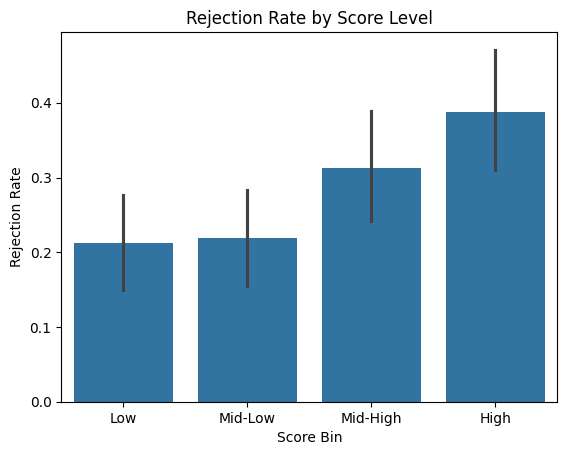

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x="score_bin", y="is_rejected")
plt.title("Rejection Rate by Score Level")
plt.ylabel("Rejection Rate")
plt.xlabel("Score Bin")
plt.show()

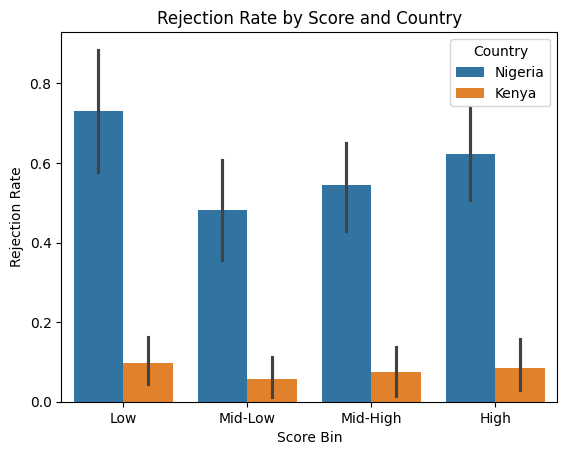

In [ ]:
sns.barplot(data=df_filtered, x="score_bin", y="is_rejected", hue="current_country")
plt.title("Rejection Rate by Score and Country")
plt.ylabel("Rejection Rate")
plt.xlabel("Score Bin")
plt.legend(title="Country")
plt.show()

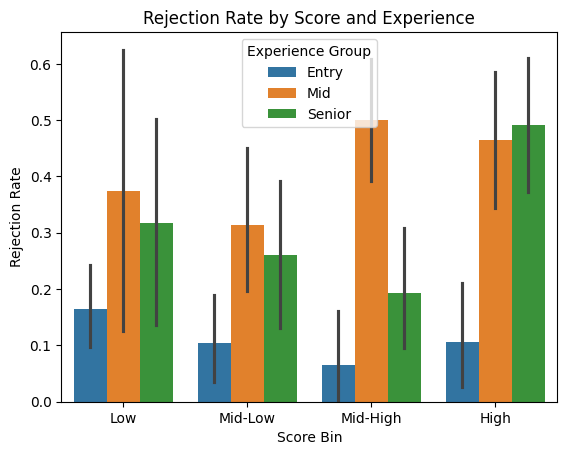

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


score_order = ["Low", "Mid-Low", "Mid-High", "High"]
sns.barplot(
    data=df,
    x="score_bin",
    y="is_rejected",
    hue="experience_group",
    order=score_order
)

plt.title("Rejection Rate by Score and Experience")
plt.ylabel("Rejection Rate")
plt.xlabel("Score Bin")
plt.legend(title="Experience Group")
plt.show()

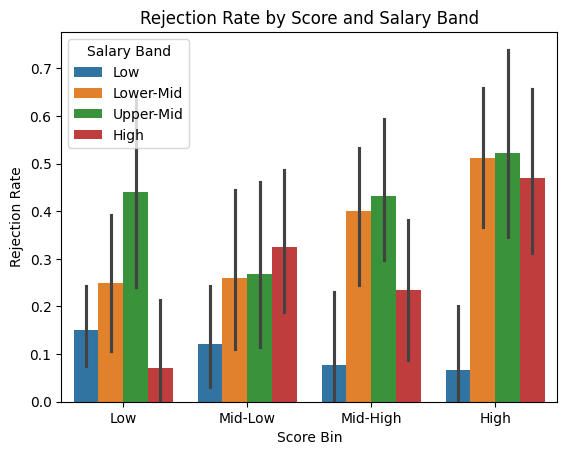

In [ ]:
salary_order = ["Low", "Lower-Mid", "Upper-Mid", "High"]

sns.barplot(
    data=df,
    x="score_bin",
    y="is_rejected",
    hue="salary_band",
    order=score_order,
    hue_order=salary_order
)

plt.title("Rejection Rate by Score and Salary Band")
plt.ylabel("Rejection Rate")
plt.xlabel("Score Bin")
plt.legend(title="Salary Band")
plt.show()

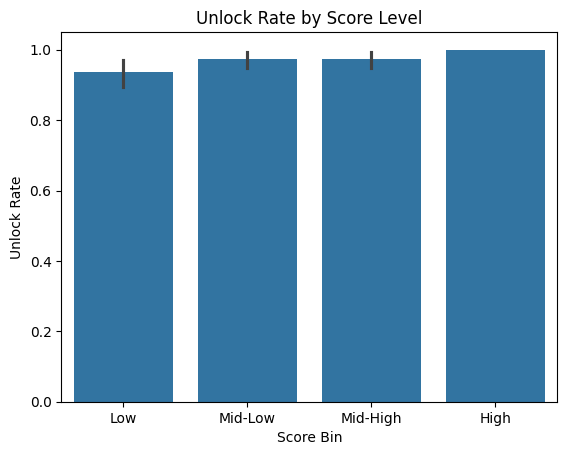

In [ ]:
sns.barplot(data=df, x="score_bin", y="is_unlocked")
plt.title("Unlock Rate by Score Level")
plt.ylabel("Unlock Rate")
plt.xlabel("Score Bin")
plt.show()

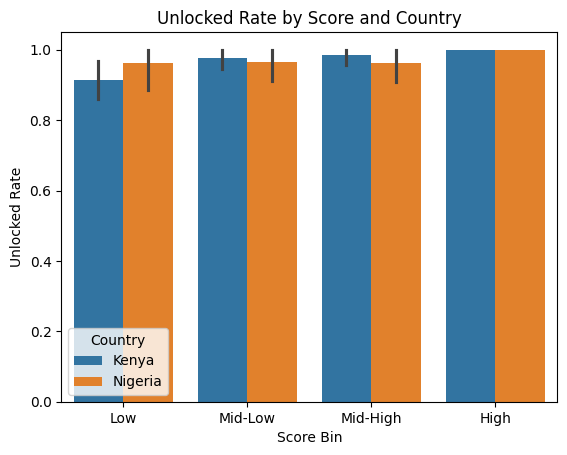

In [ ]:
sns.barplot(data=df_filtered, x="score_bin", y="is_unlocked", hue="current_country")
plt.title("Unlocked Rate by Score and Country")
plt.ylabel("Unlocked Rate")
plt.xlabel("Score Bin")
plt.legend(title="Country")
plt.show()

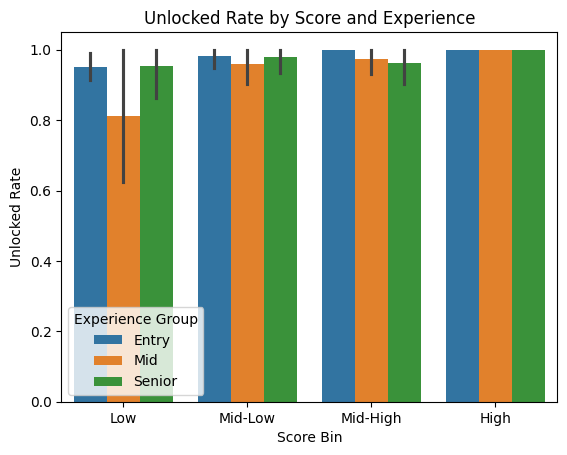

In [ ]:
sns.barplot(
    data=df,
    x="score_bin",
    y="is_unlocked",
    hue="experience_group",
    order=score_order
)

plt.title("Unlocked Rate by Score and Experience")
plt.ylabel("Unlocked Rate")
plt.xlabel("Score Bin")
plt.legend(title="Experience Group")
plt.show()

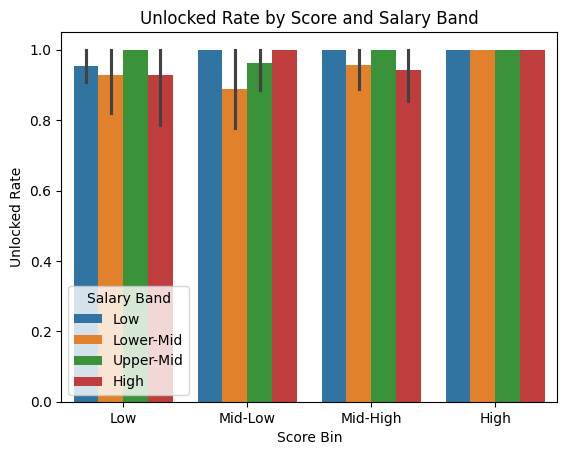

In [ ]:
sns.barplot(
    data=df,
    x="score_bin",
    y="is_unlocked",
    hue="salary_band",
    order=score_order,
    hue_order=salary_order
)

plt.title("Unlocked Rate by Score and Salary Band")
plt.ylabel("Unlocked Rate")
plt.xlabel("Score Bin")
plt.legend(title="Salary Band")
plt.show()

In [ ]:
import re

def clean_col(name):
    name = name.lower()
    name = re.sub(r'[^a-z0-9_]+', '_', name)  # replace spaces/symbols
    name = re.sub(r'_+', '_', name)           # collapse underscores
    return name.strip('_')

dim_avg.columns = (
    ['project_candidate_id'] +
    [f"dim_{clean_col(c)}" for c in dim_avg.columns if c != 'project_candidate_id']
)

In [ ]:
# ============================================================
# FULL PIPELINE — Recruiter Decision Drivers + Bias Detection
# Tests:
# 1. Overall score influence
# 2. Question-level influence (mean, std, min, max)
# 3. Dimension-level influence
# 4. Bias: country, experience, salary
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import re

# ────────────────────────────────────────────────────────────
# 0. PREP
# ────────────────────────────────────────────────────────────

df = df_combined.copy()

# Fix naming
df = df.rename(columns={"answer_score_ai": "score_ai"})

# Experience grouping
def map_experience(level):
    if pd.isna(level):
        return "Unknown"
    if level in {"entry-level", "emerging-talent"}:
        return "Entry"
    elif level in {"mid-level"}:
        return "Mid"
    elif level in {"senior", "expert"}:
        return "Senior"
    return "Other"

df["experience_group"] = df["experience_level"].apply(map_experience)

# Salary midpoint
df["salary_midpoint"] = (
    df["desired_salary_min"] + df["desired_salary_max"]
) / 2

# Canonical score fallback
if "canonical_score_ai" not in df.columns:
    df["canonical_score_ai"] = df["overall_score_ai"]

# ────────────────────────────────────────────────────────────
# 1. CANDIDATE BASE
# ────────────────────────────────────────────────────────────

df_candidate = (
    df
    .drop_duplicates(subset="project_candidate_id")
    [[
        "project_candidate_id",
        "current_country",
        "experience_group",
        "salary_midpoint",
        "canonical_score_ai",
        "overall_score_ai",
        "is_unlocked",
        "is_rejected"
    ]]
    .copy()
)

# Keep only decisions
df_candidate = df_candidate[
    (df_candidate["is_rejected"] == 1) |
    (df_candidate["is_unlocked"] == 1)
].copy()

# ────────────────────────────────────────────────────────────
# 2. QUESTION-LEVEL FEATURES
# ────────────────────────────────────────────────────────────

q_features = (
    df.groupby("project_candidate_id")["score_ai"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

q_features.columns = [
    "project_candidate_id",
    "q_mean", "q_std", "q_min", "q_max", "q_count"
]

# Fill std NaNs (single-question candidates)
q_features["q_std"] = q_features["q_std"].fillna(0)

# ────────────────────────────────────────────────────────────
# 3. DIMENSION-LEVEL FEATURES
# ────────────────────────────────────────────────────────────

def clean_col(name):
    name = str(name).lower()
    name = re.sub(r'[^a-z0-9_]+', '_', name)
    name = re.sub(r'_+', '_', name)
    return name.strip('_')

dim_avg = (
    df.groupby(["project_candidate_id", "dimension"])["score_ai"]
    .mean()
    .unstack()
    .reset_index()
)

dim_avg.columns = (
    ["project_candidate_id"] +
    [f"dim_{clean_col(c)}" for c in dim_avg.columns if c != "project_candidate_id"]
)

dim_cols = [c for c in dim_avg.columns if c.startswith("dim_")]

# Fill missing dims with median
for col in dim_cols:
    dim_avg[col] = dim_avg[col].fillna(dim_avg[col].median())

# ────────────────────────────────────────────────────────────
# 4. MERGE ALL FEATURES
# ────────────────────────────────────────────────────────────

df_model = (
    df_candidate
    .merge(q_features, on="project_candidate_id", how="left")
    .merge(dim_avg, on="project_candidate_id", how="left")
)

# Filter countries (sample size control)
country_counts = df_model["current_country"].value_counts()
valid_countries = country_counts[country_counts >= 30].index
df_model = df_model[df_model["current_country"].isin(valid_countries)].copy()

print(f"\nDataset shape: {df_model.shape}")
print(f"Rejection rate: {df_model['is_rejected'].mean():.2%}")
print(f"Countries: {df_model['current_country'].value_counts().to_dict()}")

# ────────────────────────────────────────────────────────────
# 5. MODELS
# ────────────────────────────────────────────────────────────

# Model A — Overall score
formula_A = """
is_rejected ~ canonical_score_ai
+ C(experience_group) + C(current_country) + salary_midpoint
"""

logit_A = smf.logit(formula_A, data=df_model).fit(disp=False)

# Model B — Question-level features
formula_B = """
is_rejected ~ q_mean + q_std + q_min + q_max + q_count
+ C(experience_group) + C(current_country) + salary_midpoint
"""

logit_B = smf.logit(formula_B, data=df_model).fit(disp=False)

# Model C — Dimension-level
dim_formula = " + ".join(dim_cols)
formula_C = f"""
is_rejected ~ {dim_formula}
+ C(experience_group) + C(current_country) + salary_midpoint
"""

logit_C = smf.logit(formula_C, data=df_model).fit(disp=False)

# Model D — Combined
formula_D = f"""
is_rejected ~ canonical_score_ai
+ q_mean + q_std + q_min + q_max
+ {dim_formula}
+ C(experience_group) + C(current_country) + salary_midpoint
"""

logit_D = smf.logit(formula_D, data=df_model).fit(disp=False)

# ────────────────────────────────────────────────────────────
# 6. MODEL COMPARISON
# ────────────────────────────────────────────────────────────

def pseudo_r2(m):
    return 1 - (m.llf / m.llnull)

comparison = pd.DataFrame({
    "Model": ["A: Overall", "B: Question", "C: Dimension", "D: Combined"],
    "Pseudo_R2": [pseudo_r2(m) for m in [logit_A, logit_B, logit_C, logit_D]],
    "AIC": [m.aic for m in [logit_A, logit_B, logit_C, logit_D]],
    "N": [int(m.nobs) for m in [logit_A, logit_B, logit_C, logit_D]]
}).round(4)

print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

# ────────────────────────────────────────────────────────────
# 7. LIKELIHOOD TESTS
# ────────────────────────────────────────────────────────────

def lr_test(m1, m2, name):
    lr = -2 * (m1.llf - m2.llf)
    df_diff = m2.df_model - m1.df_model
    p = stats.chi2.sf(lr, df_diff)
    print(f"\n{name}")
    print(f"LR stat={lr:.2f}, df={df_diff}, p={p:.4f}")

lr_test(logit_A, logit_B, "Question vs Overall")
lr_test(logit_A, logit_C, "Dimension vs Overall")
lr_test(logit_A, logit_D, "Full model vs Overall")

# ────────────────────────────────────────────────────────────
# 8. KEY INTERPRETATION TABLES
# ────────────────────────────────────────────────────────────

def extract_results(model):
    res = model.summary2().tables[1].reset_index()
    res.columns = ["var","coef","se","z","p","ci_low","ci_high"]
    res["odds_ratio"] = np.exp(res["coef"])
    return res

# Question-level effects
q_results = extract_results(logit_B)
print("\n=== QUESTION-LEVEL EFFECTS ===")
print(q_results[q_results["var"].str.contains("q_")][["var","coef","p","odds_ratio"]])

# Dimension effects
d_results = extract_results(logit_C)
print("\n=== DIMENSION EFFECTS ===")
print(d_results[d_results["var"].str.startswith("dim_")][["var","coef","p","odds_ratio"]])

# Bias (country + experience + salary)
bias_results = extract_results(logit_D)
print("\n=== BIAS EFFECTS (CONTROLLED) ===")
print(bias_results[
    (bias_results["var"].str.contains("current_country")) |
    (bias_results["var"].str.contains("experience_group")) |
    (bias_results["var"].str.contains("salary_midpoint"))
][["var","coef","p","odds_ratio"]])


Dataset shape: (587, 20)
Rejection rate: 23.85%
Countries: {'Kenya': 351, 'Nigeria': 236}

=== MODEL COMPARISON ===
       Model  Pseudo_R2      AIC   N
  A: Overall     0.2442 407.7516 435
 B: Question     0.1704 172.6071 269
C: Dimension     0.1470 180.9091 269
 D: Combined     0.1998 181.1894 269

Question vs Overall
LR stat=243.14, df=4.0, p=0.0000

Dimension vs Overall
LR stat=238.84, df=6.0, p=0.0000

Full model vs Overall
LR stat=248.56, df=11.0, p=0.0000

=== QUESTION-LEVEL EFFECTS ===
       var      coef         p  odds_ratio
4   q_mean  0.544979  0.392923    1.724572
5    q_std  2.631442  0.060747   13.893792
6    q_min  0.814678  0.145407    2.258448
7    q_max -1.665566  0.017259    0.189084
8  q_count  0.007330  0.780108    1.007357

=== DIMENSION EFFECTS ===
                                  var      coef         p  odds_ratio
4   dim_adaptability_learning_agility  0.095690  0.731831    1.100418
5                       dim_cognitive -0.587918  0.088955    0.555482
6    